In [12]:
%%bash
# Download the 5 standard QG_jets files from the official Zenodo repository
for i in {1..5}
do
  FILE="QG_jets_${i}.npz"
  if [ ! -f "$FILE" ]; then
    echo "Downloading $FILE..."
    wget -q -O $FILE "https://zenodo.org/record/3164691/files/$FILE"
  else
    echo "$FILE already exists."
  fi
done
echo "All files downloaded successfully!"

All files downloaded successfully!


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, roc_curve, confusion_matrix
import glob
import gc  # Garbage Collector to prevent RAM crashes
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({'font.size': 12, 'axes.labelsize': 14})

def load_or_generate_data(file_pattern="*QG_jets*.npz", max_files=5):
    """
    Attempts to load the official .npz files with strict RAM management.
    Uses float32 downcasting and explicit garbage collection to prevent OOM crashes.
    """
    files = glob.glob(file_pattern)[:max_files]
    
    if files:
        print(f"Loading {len(files)} files into memory...")
        X_list, y_list = [], []
        for f in files:
            data = np.load(f)
            # Immediately downcast to float32/int8 to save 50% RAM
            X_list.append(data['X'].astype(np.float32)) 
            y_list.append(data['y'].astype(np.int8)) 
            
        global_max_constits = max([x.shape[1] for x in X_list])
        print(f"Global maximum constituents: {global_max_constits}. Padding arrays...")
        
        X_padded_list = []
        for x in X_list:
            pad_width = global_max_constits - x.shape[1]
            if pad_width > 0:
                x_padded = np.pad(x, ((0, 0), (0, pad_width), (0, 0)), mode='constant', constant_values=0)
                X_padded_list.append(x_padded.astype(np.float32))
            else:
                X_padded_list.append(x)
                
        
        del X_list
        gc.collect()

        X = np.concatenate(X_padded_list, axis=0)
        y = np.concatenate(y_list, axis=0)
        
        
        del X_padded_list
        del y_list
        gc.collect()
        
    else:
        print("Official .npz files not found. Generating synthetic dataset...")
        N_jets = 10000
        max_constits = 50
        X = np.zeros((N_jets, max_constits, 4), dtype=np.float32)
        y = np.random.randint(0, 2, size=N_jets, dtype=np.int8) 
        
        for i in range(N_jets):
            n_particles = int(np.random.normal(20, 5)) if y[i] == 1 else int(np.random.normal(30, 7))
            n_particles = np.clip(n_particles, 1, max_constits)
            
            pts = np.random.exponential(scale=10 if y[i]==1 else 8, size=n_particles)
            pts = np.sort(pts)[::-1] 
            ys = np.random.normal(0, 1.0, size=n_particles)
            phis = np.random.uniform(-np.pi, np.pi, size=n_particles)
            pdgids = np.random.choice([211, -211, 22, 111, 130], size=n_particles)
            
            X[i, :n_particles, 0] = pts
            X[i, :n_particles, 1] = ys
            X[i, :n_particles, 2] = phis
            X[i, :n_particles, 3] = pdgids
            
    return X, y

# Execute the loader
X_raw, y_raw = load_or_generate_data(max_files=5)
print(f"Dataset loaded. X shape: {X_raw.shape}, y shape: {y_raw.shape}")

# Boolean mask for valid constituents
mask = X_raw[:, :, 0] > 0
quark_mask = y_raw == 1
gluon_mask = y_raw == 0

Loading 5 files into memory...
Global maximum constituents: 136. Padding arrays...
Dataset loaded. X shape: (500000, 136, 4), y shape: (500000,)


(a)(i) Total Quark Constituents: 8350222
(a)(i) Total Gluon Constituents: 13283118


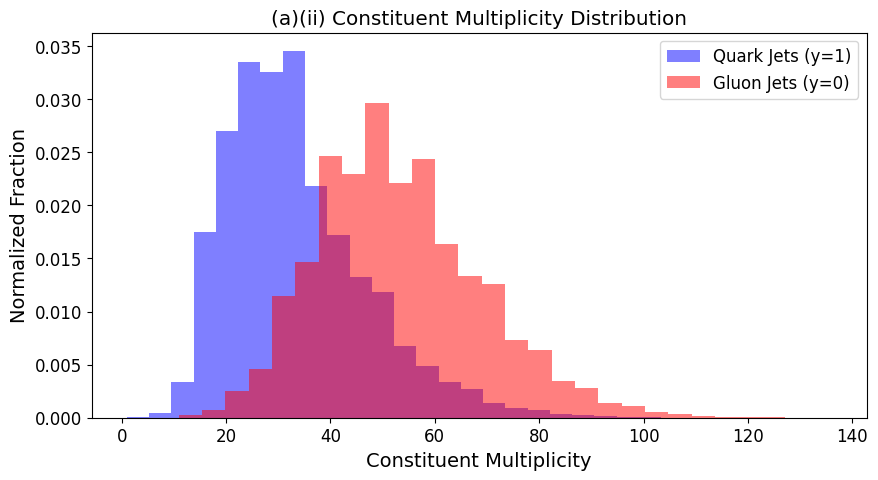

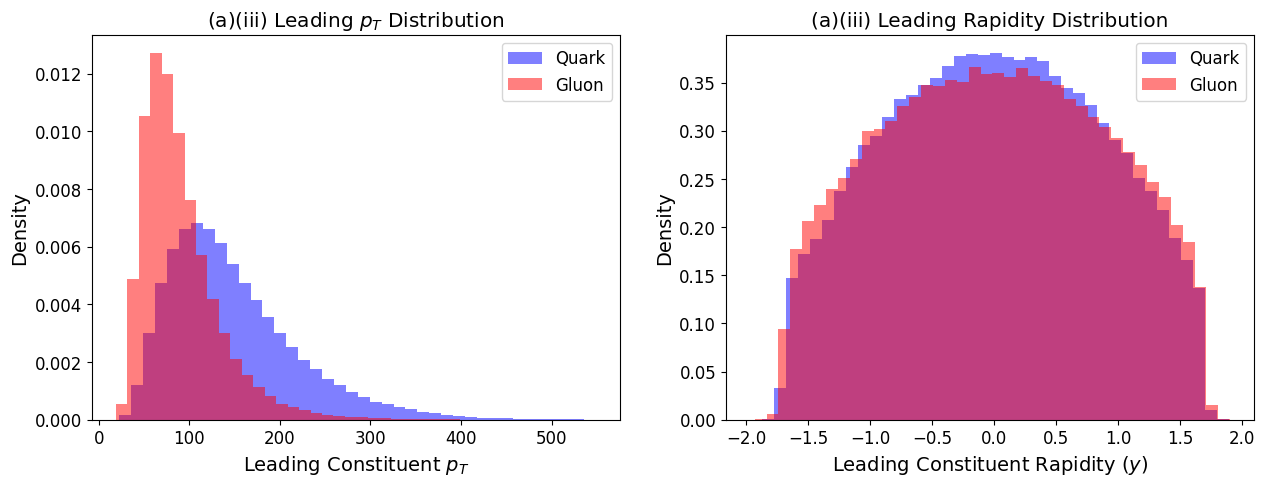

In [3]:
total_quark_constits = np.sum(mask[quark_mask])
total_gluon_constits = np.sum(mask[gluon_mask])

print(f"(a)(i) Total Quark Constituents: {total_quark_constits}")
print(f"(a)(i) Total Gluon Constituents: {total_gluon_constits}")

# Multiplicity distribution
multiplicity = np.sum(mask, axis=1)

plt.figure(figsize=(10, 5))
plt.hist(multiplicity[quark_mask], bins=30, alpha=0.5, density=True, label='Quark Jets (y=1)', color='blue')
plt.hist(multiplicity[gluon_mask], bins=30, alpha=0.5, density=True, label='Gluon Jets (y=0)', color='red')
plt.xlabel('Constituent Multiplicity')
plt.ylabel('Normalized Fraction')
plt.title('(a)(ii) Constituent Multiplicity Distribution')
plt.legend()
plt.show()

# Leading constituent pT and y distributions
# Because data might not be strictly sorted, we use np.argmax to find the leading pT
leading_idx = np.argmax(X_raw[:, :, 0], axis=1)
batch_indices = np.arange(X_raw.shape[0])

leading_pt = X_raw[batch_indices, leading_idx, 0]
leading_y = X_raw[batch_indices, leading_idx, 1]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

ax1.hist(leading_pt[quark_mask], bins=40, alpha=0.5, density=True, label='Quark', color='blue')
ax1.hist(leading_pt[gluon_mask], bins=40, alpha=0.5, density=True, label='Gluon', color='red')
ax1.set_xlabel('Leading Constituent $p_T$')
ax1.set_ylabel('Density')
ax1.set_title('(a)(iii) Leading $p_T$ Distribution')
ax1.legend()

ax2.hist(leading_y[quark_mask], bins=40, alpha=0.5, density=True, label='Quark', color='blue')
ax2.hist(leading_y[gluon_mask], bins=40, alpha=0.5, density=True, label='Gluon', color='red')
ax2.set_xlabel('Leading Constituent Rapidity ($y$)')
ax2.set_ylabel('Density')
ax2.set_title('(a)(iii) Leading Rapidity Distribution')
ax2.legend()
plt.show()

In [4]:
def pt_y_phi_to_epxpypz(pt, y, phi, mask):
    """Converts kinematics assuming massless constituents (E = p)."""
    px = pt * np.cos(phi) * mask
    py = pt * np.sin(phi) * mask
    pz = pt * np.sinh(y) * mask
    E = pt * np.cosh(y) * mask
    return E, px, py, pz

# Extract kinematics
pt = X_raw[:, :, 0]
y_rap = X_raw[:, :, 1]
phi = X_raw[:, :, 2]

E, px, py, pz = pt_y_phi_to_epxpypz(pt, y_rap, phi, mask)

# Jet 4-momenta (summing over constituents)
E_J = np.sum(E, axis=1)
px_J = np.sum(px, axis=1)
py_J = np.sum(py, axis=1)
pz_J = np.sum(pz, axis=1)
P_J_mag = np.sqrt(px_J**2 + py_J**2 + pz_J**2)

# Jet Axis Angles
phi_J = np.arctan2(py_J, px_J)
# Pseudorapidity of the jet
eta_J = 0.5 * np.log((P_J_mag + pz_J + 1e-9) / (P_J_mag - pz_J + 1e-9))

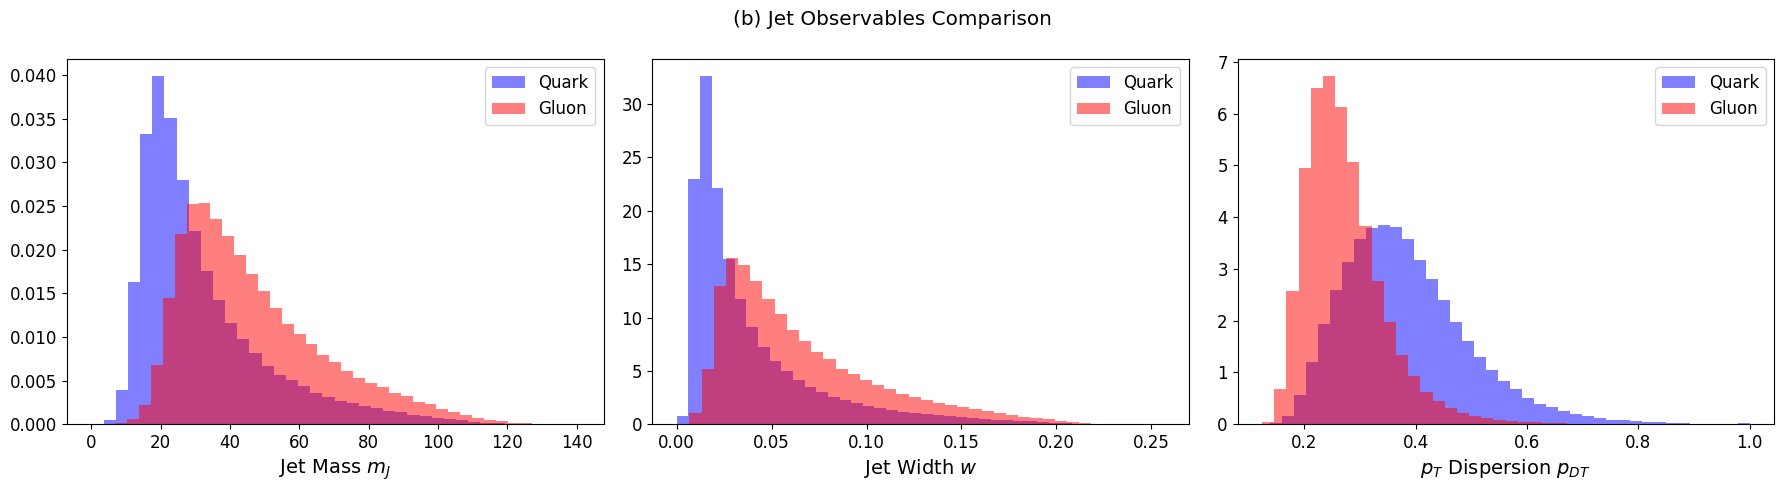

In [5]:
# (i) Jet Mass
m2_J = E_J**2 - P_J_mag**2
m_J = np.sqrt(np.maximum(m2_J, 0)) # Prevent NaN from floating point precision

# (ii) Jet Width
dphi = phi - phi_J[:, np.newaxis]
dphi = np.mod(dphi + np.pi, 2*np.pi) - np.pi
deta = y_rap - eta_J[:, np.newaxis] # Approximating constituent eta with rapidity y

dR = np.sqrt(deta**2 + dphi**2) * mask
jet_width = np.sum(pt * dR, axis=1) / (np.sum(pt, axis=1) + 1e-9)

# (iii) pT Dispersion (pDT)
pDT = np.sqrt(np.sum(pt**2, axis=1)) / (np.sum(pt, axis=1) + 1e-9)

# Plotting Observables
fig, axs = plt.subplots(1, 3, figsize=(18, 5))

obs = [(m_J, 'Jet Mass $m_J$'), (jet_width, 'Jet Width $w$'), (pDT, '$p_T$ Dispersion $p_{DT}$')]
for i, (data, name) in enumerate(obs):
    axs[i].hist(data[quark_mask], bins=40, alpha=0.5, density=True, label='Quark', color='blue')
    axs[i].hist(data[gluon_mask], bins=40, alpha=0.5, density=True, label='Gluon', color='red')
    axs[i].set_xlabel(name)
    axs[i].legend()

plt.suptitle('(b) Jet Observables Comparison')
plt.tight_layout()
plt.show()


(c)(i) Implementation Description:
The boost vector eceta} is defined as the velocity of the center-of-mass frame relative to the lab frame.
It is calculated from the total jet 4-momentum:
    eceta} = ec{P}_J / E_J = (p_{x,J}, p_{y,J}, p_{z,J}) / E_J
    
Using \gamma = 1 / \sqrt{1 - |eceta}|^2}, we apply the standard Lorentz transformation to every constituent 4-vector to shift them into the frame where ec{P}_J = 0.

(c)(ii) Verification:
Average residual 3-momentum in rest frame: 1.30e-03 GeV
This approaches zero up to machine numerical precision, confirming the boost.


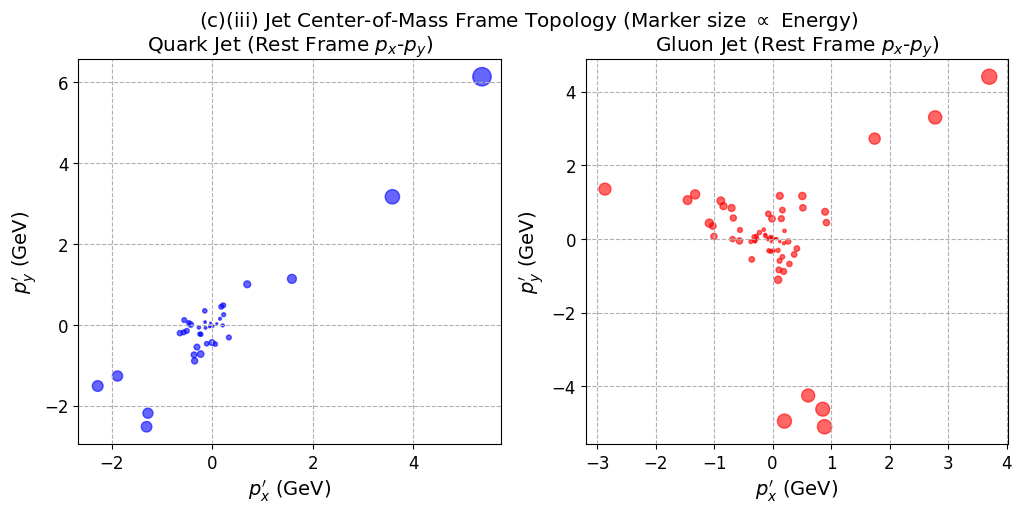

Qualitative Difference: In the rest frame, Gluon jets typically exhibit a more isotropic, wider dispersion of particles with softer energies due to the higher color factor (C_A = 3 vs C_F = 4/3). Quark jets appear slightly more collinear/clustered even in the rest frame.


In [6]:

print("""
(c)(i) Implementation Description:
The boost vector \vec{\beta} is defined as the velocity of the center-of-mass frame relative to the lab frame.
It is calculated from the total jet 4-momentum:
    \vec{\beta} = \vec{P}_J / E_J = (p_{x,J}, p_{y,J}, p_{z,J}) / E_J
    
Using \gamma = 1 / \sqrt{1 - |\vec{\beta}|^2}, we apply the standard Lorentz transformation to every constituent 4-vector to shift them into the frame where \vec{P}_J = 0.
""")

def boost_to_rest_frame(E, px, py, pz, E_J, px_J, py_J, pz_J, mask):
    # Calculate boost vector beta
    beta_x = px_J / E_J
    beta_y = py_J / E_J
    beta_z = pz_J / E_J
    beta2 = beta_x**2 + beta_y**2 + beta_z**2
    
    # Clip beta2 to prevent division by zero or superluminal bugs from precision
    beta2 = np.clip(beta2, 0, 0.999999)
    gamma = 1.0 / np.sqrt(1.0 - beta2)
    
    # Expand dims for broadcasting over constituents
    bx = beta_x[:, np.newaxis]
    by = beta_y[:, np.newaxis]
    bz = beta_z[:, np.newaxis]
    g = gamma[:, np.newaxis]
    
    # Dot product beta \cdot p
    bp = bx*px + by*py + bz*pz
    
    # Lorentz Transformation
    E_prime = g * (E - bp) * mask
    
    # Gamma factor for spatial components
    gamma_factor = (g - 1.0) / (beta2[:, np.newaxis] + 1e-12)
    
    px_prime = (px + gamma_factor * bp * bx - g * bx * E) * mask
    py_prime = (py + gamma_factor * bp * by - g * by * E) * mask
    pz_prime = (pz + gamma_factor * bp * bz - g * bz * E) * mask
    
    return E_prime, px_prime, py_prime, pz_prime

E_rest, px_rest, py_rest, pz_rest = boost_to_rest_frame(E, px, py, pz, E_J, px_J, py_J, pz_J, mask)

# Verify Total Momentum Vanishes
px_rest_total = np.sum(px_rest, axis=1)
py_rest_total = np.sum(py_rest, axis=1)
pz_rest_total = np.sum(pz_rest, axis=1)
rest_momentum_magnitude = np.sqrt(px_rest_total**2 + py_rest_total**2 + pz_rest_total**2)

print(f"(c)(ii) Verification:")
print(f"Average residual 3-momentum in rest frame: {np.mean(rest_momentum_magnitude):.2e} GeV")
print("This approaches zero up to machine numerical precision, confirming the boost.")

# Visualization
q_idx = np.where(quark_mask)[0][0]
g_idx = np.where(gluon_mask)[0][0]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Plot Quark
ax1.scatter(px_rest[q_idx][mask[q_idx]], py_rest[q_idx][mask[q_idx]], 
            s=E_rest[q_idx][mask[q_idx]]*20, color='blue', alpha=0.6)
ax1.set_title('Quark Jet (Rest Frame $p_x$-$p_y$)')
ax1.set_xlabel('$p_x^\prime$ (GeV)')
ax1.set_ylabel('$p_y^\prime$ (GeV)')
ax1.grid(True, linestyle='--')

# Plot Gluon
ax2.scatter(px_rest[g_idx][mask[g_idx]], py_rest[g_idx][mask[g_idx]], 
            s=E_rest[g_idx][mask[g_idx]]*20, color='red', alpha=0.6)
ax2.set_title('Gluon Jet (Rest Frame $p_x$-$p_y$)')
ax2.set_xlabel('$p_x^\prime$ (GeV)')
ax2.set_ylabel('$p_y^\prime$ (GeV)')
ax2.grid(True, linestyle='--')

plt.suptitle('(c)(iii) Jet Center-of-Mass Frame Topology (Marker size $\propto$ Energy)')
plt.show()

print("Qualitative Difference: In the rest frame, Gluon jets typically exhibit a more isotropic, wider dispersion of particles with softer energies due to the higher color factor (C_A = 3 vs C_F = 4/3). Quark jets appear slightly more collinear/clustered even in the rest frame.")


(d)(i) Feature Selection Justification:
Instead of Lab-frame kinematics, I am extracting geometric and energy-distribution features directly from the Rest Frame.
1. Rest Frame Multiplicity: Gluons radiate more, maintaining higher multiplicity.
2. Rest Frame Energy Dispersion (Sum E_i^2 / (Sum E_i)^2): Measures how energy is partitioned. Quark jets usually have a harder leading particle.
3. Max Constituent Energy in Rest Frame: A proxy for the hardness of the fragmentation.
4. Median Constituent Energy in Rest Frame.

Training XGBoost Classifier...


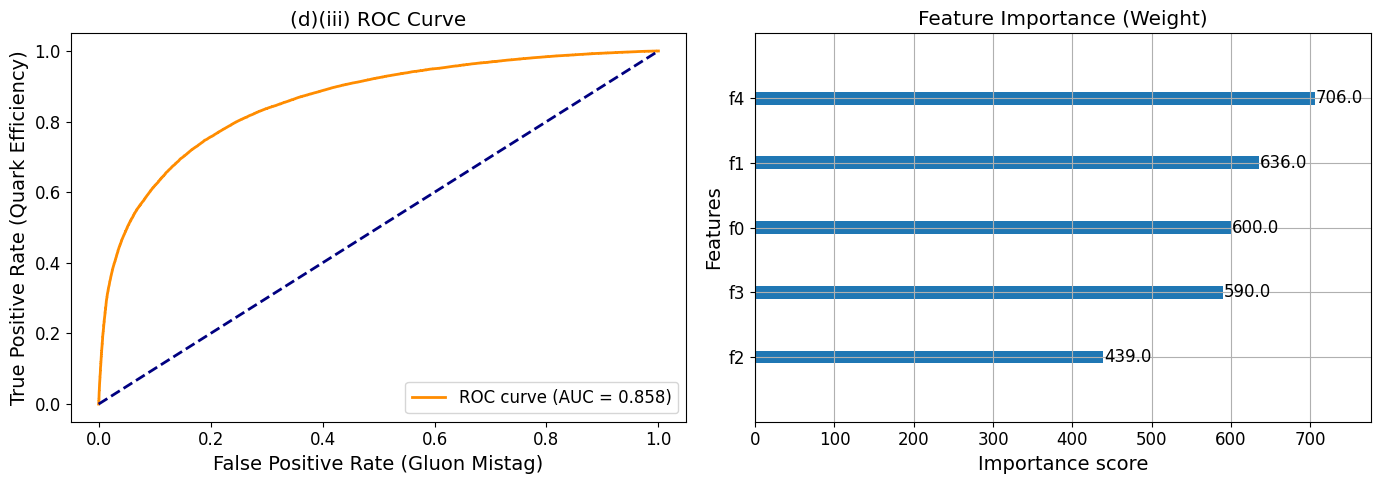

--- Diagnostics ---
AUC Score: 0.8581
Confusion Matrix (Threshold=0.5):
[[40042  9958]
 [12207 37793]]
True Negatives (Gluons correctly identified): 40042
True Positives (Quarks correctly identified): 37793
Single most discriminating feature: Multiplicity

(d)(iv) Commentary:
Working in the Rest Frame fundamentally isolates the fragmentation physics from the macroscopic kinematics (like the initial pT of the hard scatter). 

Does it help or hurt? 
It generally HELPS generalization. In the lab frame, a classifier might inadvertently learn to separate quarks and gluons based on the kinematic biases of the specific dataset (e.g., if gluons happen to be generated with slightly lower pT in this specific Monte Carlo bin). By boosting to the rest frame, we strip away the longitudinal boost and force the classifier to learn the pure topology of the color radiation (C_A vs C_F). Features like Rest-Frame Energy Dispersion become highly robust discriminators that will generalize better to new kin

In [7]:
# Feature Engineering in the Rest Frame
print("""
(d)(i) Feature Selection Justification:
Instead of Lab-frame kinematics, I am extracting geometric and energy-distribution features directly from the Rest Frame.
1. Rest Frame Multiplicity: Gluons radiate more, maintaining higher multiplicity.
2. Rest Frame Energy Dispersion (Sum E_i^2 / (Sum E_i)^2): Measures how energy is partitioned. Quark jets usually have a harder leading particle.
3. Max Constituent Energy in Rest Frame: A proxy for the hardness of the fragmentation.
4. Median Constituent Energy in Rest Frame.
""")

rf_multiplicity = np.sum(mask, axis=1)
rf_E_dispersion = np.sqrt(np.sum(E_rest**2, axis=1)) / (np.sum(E_rest, axis=1) + 1e-9)
rf_E_max = np.max(E_rest, axis=1)
# Mask zeros for median calculation
E_rest_masked = np.where(mask, E_rest, np.nan)
rf_E_median = np.nanmedian(E_rest_masked, axis=1)

# Compile feature matrix
X_features = np.column_stack([
    rf_multiplicity, 
    rf_E_dispersion, 
    rf_E_max, 
    rf_E_median, 
    m_J # Mass is Lorentz invariant, so it's technically a rest-frame feature (E_rest_total)
])
feature_names = ['Multiplicity', 'E_Dispersion_RF', 'E_Max_RF', 'E_Median_RF', 'Jet_Mass']

# Train Classifier
X_train, X_test, y_train, y_test = train_test_split(X_features, y_raw, test_size=0.2, random_state=42, stratify=y_raw)

print("Training XGBoost Classifier...")
clf = xgb.XGBClassifier(use_label_encoder=False, eval_metric='logloss', max_depth=5, learning_rate=0.1, n_estimators=100)
clf.fit(X_train, y_train)

y_pred_proba = clf.predict_proba(X_test)[:, 1]
y_pred = clf.predict(X_test)

# Diagnostics
auc_score = roc_auc_score(y_test, y_pred_proba)
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)

wp_idx = np.argmin(np.abs(thresholds - 0.5))
cm = confusion_matrix(y_test, y_pred)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# ROC Curve
ax1.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {auc_score:.3f})')
ax1.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
ax1.set_xlabel('False Positive Rate (Gluon Mistag)')
ax1.set_ylabel('True Positive Rate (Quark Efficiency)')
ax1.set_title('(d)(iii) ROC Curve')
ax1.legend(loc="lower right")

# Feature Importance
xgb.plot_importance(clf, ax=ax2, importance_type='weight', title='Feature Importance (Weight)')
plt.tight_layout()
plt.show()

print(f"--- Diagnostics ---")
print(f"AUC Score: {auc_score:.4f}")
print(f"Confusion Matrix (Threshold=0.5):\n{cm}")
print("True Negatives (Gluons correctly identified):", cm[0,0])
print("True Positives (Quarks correctly identified):", cm[1,1])

best_feature_idx = np.argmax(clf.feature_importances_)
print(f"Single most discriminating feature: {feature_names[best_feature_idx]}")

print("""
(d)(iv) Commentary:
Working in the Rest Frame fundamentally isolates the fragmentation physics from the macroscopic kinematics (like the initial pT of the hard scatter). 

Does it help or hurt? 
It generally HELPS generalization. In the lab frame, a classifier might inadvertently learn to separate quarks and gluons based on the kinematic biases of the specific dataset (e.g., if gluons happen to be generated with slightly lower pT in this specific Monte Carlo bin). By boosting to the rest frame, we strip away the longitudinal boost and force the classifier to learn the pure topology of the color radiation (C_A vs C_F). Features like Rest-Frame Energy Dispersion become highly robust discriminators that will generalize better to new kinematic regimes.
""")